In [1]:
#import librairie nécessaire
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
#je regarde un fichier pour voir déjà à quoi il ressemble
synop_2021 = pd.read_csv(
    "../data/raw/Synop Meteo/synop_2021.csv.gz", 
    sep=";"
)

display(synop_2021.head(10))

,lat,lon,geo_id_wmo,geo_id_wigos,name,reference_time,insert_time,validity_time,pmer,tend,...,hnuage1,nnuage2,ctype2,hnuage2,nnuage3,ctype3,hnuage3,nnuage4,ctype4,hnuage4
0,50.136000,1.834000,7005,0-20000-0-07005,ABBEVILLE,NaN,NaN,2021-01-01T00:00:00Z,100830.0,80.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,43.648833,7.209000,7690,0-20000-0-07690,NICE,NaN,NaN,2021-01-01T00:00:00Z,100820.0,-90.0,...,1000.0,7.0,6.0,1800.0,NaN,NaN,NaN,NaN,NaN,NaN
2,47.444500,0.727333,7240,0-20000-0-07240,TOURS,NaN,NaN,2021-01-01T00:00:00Z,100800.0,40.0,...,1470.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-20.892167,55.528667,61980,0-20000-0-61980,GILLOT-AEROPORT,NaN,NaN,2021-01-01T00:00:00Z,101490.0,-80.0,...,840.0,3.0,NaN,1440.0,7.0,NaN,1680.0,NaN,9.0,NaN
4,47.059167,2.359833,7255,0-20000-0-07255,BOURGES,NaN,NaN,2021-01-01T00:00:00Z,100860.0,70.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,43.437667,5.216000,7650,0-20000-0-07650,MARIGNANE,NaN,NaN,2021-01-01T00:00:00Z,100550.0,-210.0,...,1020.0,5.0,NaN,1410.0,6.0,NaN,1680.0,NaN,8.0,NaN
6,-11.582667,47.289667,61968,0-20000-0-61968,GLORIEUSES,NaN,NaN,2021-01-01T00:00:00Z,100970.0,70.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,48.718000,2.397000,7149,0-20000-0-07149,ORLY,NaN,NaN,2021-01-01T00:00:00Z,100810.0,80.0,...,600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,48.324667,4.020000,7168,0-20000-0-07168,TROYES-BARBEREY,NaN,NaN,2021-01-01T00:00:00Z,100750.0,80.0,...,570.0,8.0,NaN,1320.0,NaN,NaN,NaN,NaN,NaN,NaN
9,4.822333,-52.365333,81405,0-20000-0-81405,CAYENNE-MATOURY,NaN,NaN,2021-01-01T00:00:00Z,101250.0,160.0,...,540.0,6.0,NaN,780.0,8.0,NaN,1680.0,NaN,8.0,NaN


In [15]:
#voir informations colonnes
# Crée un résumé propre des 65 colonnes
resume_colonnes = pd.DataFrame({
    'Type': synop_2021.dtypes,
    'Valeurs_non_nulles': synop_2021.notna().sum(),
    'Taux_complétude (%)': (synop_2021.notna().mean() * 100).round(1)
})

# Afficher TOUTES les lignes et TOUTES les colonnes uniquement pour cette commande
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(resume_colonnes)


,Type,Valeurs_non_nulles,Taux_complétude (%)
lat,float64,166227,100.0
lon,float64,166227,100.0
geo_id_wmo,int64,166227,100.0
geo_id_wigos,str,166227,100.0
name,str,166227,100.0
reference_time,float64,0,0.0
insert_time,float64,0,0.0
validity_time,str,166227,100.0
pmer,float64,160418,96.5
tend,float64,165967,99.8


Je suis en présence de 6 fichiers allant de l'année 2021 à 2026 (1 par année)
D'abord concaténer les fichiers pour n'avoir qu'un fichier de travail pour l'exploration de données

In [18]:
import glob
#concaténation fichiers synop
# 1. Lister tous les fichiers météo dans l'ordre des années
fichiers_meteo = sorted(glob.glob("../data/raw/Synop Meteo/synop_*.csv.gz"))

# 2. Charger et concaténer
df_meteo = pd.concat(
    [pd.read_csv(f, compression='gzip', sep=';') for f in fichiers_meteo], 
    ignore_index=True)

# 3. Vérifier la forme du DataFrame
print("Dimensions du jeu météo fusionné :", df_meteo.shape)
display(df_meteo.head(5))

#voir si il y a toute les années
annees_disponibles = df_meteo['validity_time'].unique()
display(annees_disponibles)


C:\Users\gauxm\AppData\Local\Temp\ipykernel_20504\2534393989.py:8: DtypeWarning: Columns (5: reference_time, 6: insert_time) have mixed types. Specify dtype option on import or set low_memory=False.
  [pd.read_csv(f, compression='gzip', sep=';') for f in fichiers_meteo],


Dimensions du jeu météo fusionné : (1390585, 65)


,lat,lon,geo_id_wmo,geo_id_wigos,name,reference_time,insert_time,validity_time,pmer,tend,cod_tend,dd,ff,t,td,u,vv,ww,w1,w2,n,nbas,hbas,cl,cm,ch,pres,niv_bar,geop,tend24,tn12,tn24,tx12,tx24,tminsol,sw,tw,raf10,rafper,per,etat_sol,ht_neige,ssfrai,perssfrai,rr1,rr3,rr6,rr12,rr24,phenspe1,phenspe2,phenspe3,phenspe4,nnuage1,ctype1,hnuage1,nnuage2,ctype2,hnuage2,nnuage3,ctype3,hnuage3,nnuage4,ctype4,hnuage4
0,50.136000,1.834000,7005,0-20000-0-07005,ABBEVILLE,NaN,NaN,2021-01-01T00:00:00Z,100830.0,80.0,1.0,340.0,1.0,271.35,270.75,96.0,13160.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99920.0,NaN,NaN,570.0,NaN,NaN,NaN,NaN,272.65,NaN,NaN,2.0,3.3,-10.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,43.648833,7.209000,7690,0-20000-0-07690,NICE,NaN,NaN,2021-01-01T00:00:00Z,100820.0,-90.0,7.0,330.0,3.0,280.15,274.85,69.0,30000.0,2.0,2.0,2.0,90.0,7.0,1250.0,35.0,NaN,NaN,100500.0,NaN,NaN,-60.0,NaN,NaN,NaN,NaN,278.25,NaN,NaN,5.0,7.5,-10.0,0.0,0.0,NaN,NaN,-0.1,-0.1,-0.1,-0.1,-0.1,NaN,NaN,NaN,NaN,2.0,6.0,1000.0,7.0,6.0,1800.0,NaN,NaN,NaN,NaN,NaN,NaN
2,47.444500,0.727333,7240,0-20000-0-07240,TOURS,NaN,NaN,2021-01-01T00:00:00Z,100800.0,40.0,0.0,340.0,0.0,273.65,273.05,96.0,8400.0,0.0,NaN,NaN,100.0,8.0,1250.0,NaN,NaN,NaN,99410.0,NaN,NaN,360.0,NaN,NaN,NaN,NaN,274.95,NaN,NaN,0.9,1.7,-10.0,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.2,NaN,NaN,NaN,NaN,8.0,NaN,1470.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-20.892167,55.528667,61980,0-20000-0-61980,GILLOT-AEROPORT,NaN,NaN,2021-01-01T00:00:00Z,101490.0,-80.0,5.0,160.0,5.0,296.25,293.55,85.0,16090.0,60.0,NaN,NaN,100.0,3.0,800.0,NaN,NaN,NaN,101340.0,NaN,NaN,130.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.6,11.5,-10.0,NaN,NaN,NaN,NaN,0.4,1.8,2.6,2.6,3.6,NaN,NaN,NaN,NaN,1.0,NaN,840.0,3.0,NaN,1440.0,7.0,NaN,1680.0,NaN,9.0,NaN
4,47.059167,2.359833,7255,0-20000-0-07255,BOURGES,NaN,NaN,2021-01-01T00:00:00Z,100860.0,70.0,1.0,0.0,0.0,272.85,272.25,96.0,7670.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98800.0,NaN,NaN,190.0,NaN,NaN,NaN,NaN,272.45,NaN,NaN,0.0,1.8,-10.0,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,7.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<StringArray>
['2021-01-01T00:00:00Z', '2021-01-01T03:00:00Z', '2021-01-01T06:00:00Z',
 '2021-01-01T09:00:00Z', '2021-01-01T12:00:00Z', '2021-01-01T15:00:00Z',
 '2021-01-01T18:00:00Z', '2021-01-01T21:00:00Z', '2021-01-02T00:00:00Z',
 '2021-01-02T03:00:00Z',
 ...
 '2026-10-06T18:00:00Z', '2026-10-06T21:00:00Z', '2026-10-07T00:00:00Z',
 '2026-10-07T03:00:00Z', '2026-10-07T06:00:00Z', '2026-10-07T09:00:00Z',
 '2026-10-07T12:00:00Z', '2026-10-07T15:00:00Z', '2026-10-07T18:00:00Z',
 '2026-10-07T21:00:00Z']
Length: 16830, dtype: str

In [21]:
#Exporter le DataFrame concaténé au format CSV compressé (.csv.gz)
# On conserve la compression gzip pour économiser de l'espace disque tout en gardant un format texte standard
df_meteo.to_csv(
    "../data/raw/Synop Meteo/synop_concat_2021_2026.csv.gz", 
    sep=";", 
    index=False, 
    compression="gzip"
)

print("Fichier concaténé sauvegardé avec succès dans '../data/raw/Synop Meteo/synop_concat_2021_2026.csv.gz' !")

Fichier concaténé sauvegardé avec succès dans '../data/raw/Synop Meteo/synop_concat_2021_2026.csv.gz' !


In [26]:
#voir informations colonnes
# Crée un résumé propre des 65 colonnes, types de données, valeurs non nulles et taux de complétude
resume_colonnes = pd.DataFrame({
    'Index': range(len(df_meteo.columns)),
    'Nom_Colonne': df_meteo.columns,
    'Type': df_meteo.dtypes.values,
    'Valeurs_Renseignees': df_meteo.notna().sum().values,
    'Valeurs_Manquantes_NA': df_meteo.isna().sum().values,
    'Taux_NA (%)': (df_meteo.isna().mean() * 100).round(2).values
})

# Afficher TOUTES les lignes et TOUTES les colonnes uniquement pour cette commande
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(resume_colonnes)

,Index,Nom_Colonne,Type,Valeurs_Renseignees,Valeurs_Manquantes_NA,Taux_NA (%)
0,0,lat,float64,1390585,0,0.00
1,1,lon,float64,1390585,0,0.00
2,2,geo_id_wmo,int64,1390585,0,0.00
3,3,geo_id_wigos,str,1390585,0,0.00
4,4,name,str,1390585,0,0.00
5,5,reference_time,object,596473,794112,57.11
6,6,insert_time,object,596473,794112,57.11
7,7,validity_time,str,1390585,0,0.00
8,8,pmer,float64,1324842,65743,4.73
9,9,tend,float64,1378365,12220,0.88


In [ ]:
#Exporter au format Excel (.xlsx) pour le rapport 
nom_fichier_excel = "../data/raw/Synop Meteo/Meteo_resume_colonnes2.xlsx"
resume_colonnes.to_excel(nom_fichier_excel, index=False, sheet_name="Colonnes_SYNOP")

print("Fichier 'Meteo_resume_colonnes2.xlsx' généré avec un seul tableau récapitulatif !")

Fichier 'Meteo_resume_colonnes2.xlsx' généré avec un seul tableau récapitulatif !


Passe à l'exploration générale des données

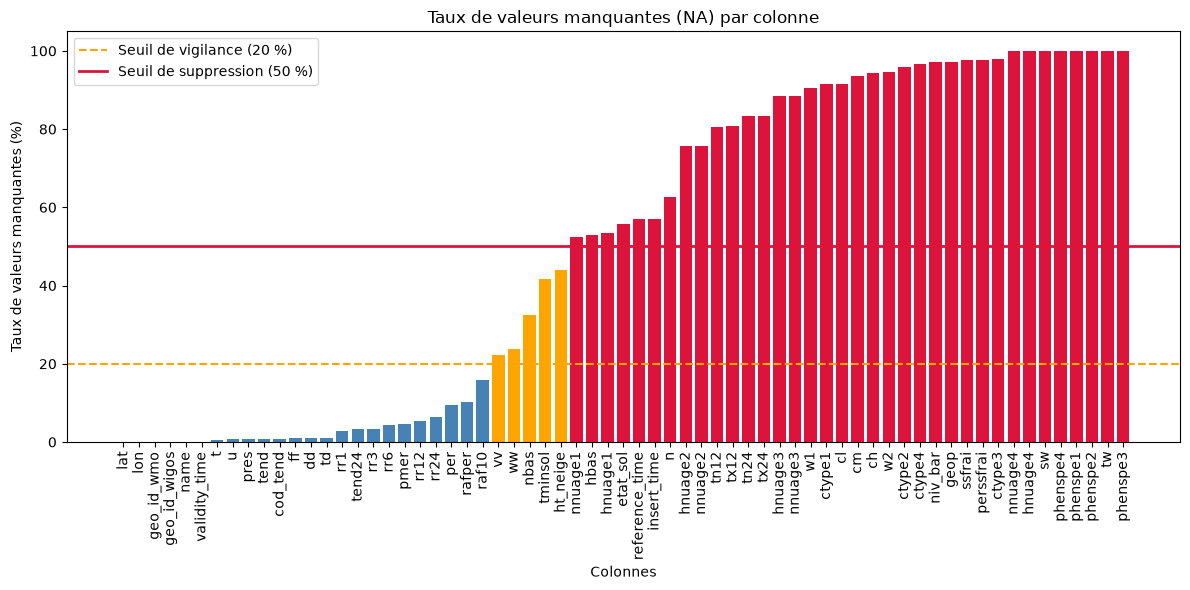

In [39]:
#graphique du taux de NA par colonne avec seuil de vigilance et seuil de suppression

# trie en fonction du taux de NA pour un affichage plus clair
resume_colonnes_tri = resume_colonnes.sort_values(by='Taux_NA (%)', ascending=True)

#Attribution des couleurs selon les seuils
couleurs = []
for val in resume_colonnes_tri['Taux_NA (%)'].values:
    if val >= 50:
        couleurs.append('crimson')       # Seuil suppression
    elif val >= 20:
        couleurs.append('orange')        # Seuil vigilance
    else:
        couleurs.append('steelblue')     # Données très complètes

#Figurre du graphique
plt.figure(figsize=(12, 6))
plt.bar(resume_colonnes_tri['Nom_Colonne'], resume_colonnes_tri['Taux_NA (%)'], color=couleurs)
plt.xticks(rotation=90)
plt.title("Taux de valeurs manquantes (NA) par colonne")
plt.xlabel("Colonnes")
plt.ylabel("Taux de valeurs manquantes (%)")
plt.axhline(y=20, color='orange', linestyle='--', linewidth=1.5, label='Seuil de vigilance (20 %)')
plt.axhline(y=50, color='crimson', linestyle='-', linewidth=2, label='Seuil de suppression (50 %)')
plt.legend()
plt.tight_layout()
plt.show()


In [40]:
#Taux de colonne qui ont > 50% de NA
colonnes_sup_50_na = resume_colonnes[resume_colonnes['Taux_NA (%)'] > 50]
print(f"Nombre de colonnes avec plus de 50% de valeurs manquantes : {colonnes_sup_50_na['Nom_Colonne'].count()}")

Nombre de colonnes avec plus de 50% de valeurs manquantes : 36


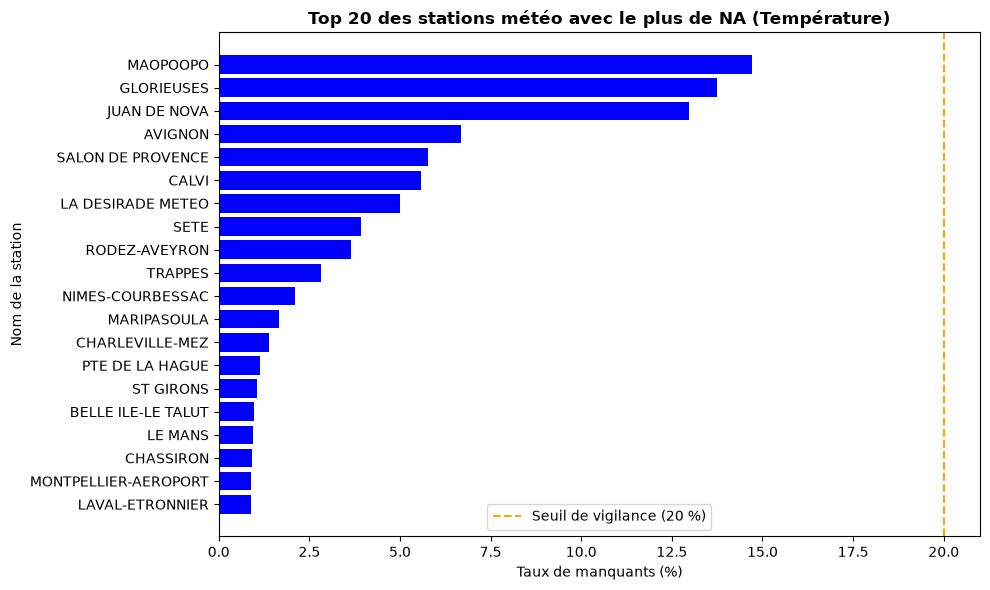

In [43]:
# Calcul du taux de NA sur la température par station
na_station = df_meteo.groupby('name')['t'].apply(lambda x: x.isna().mean() * 100).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(na_station.index[-20:], na_station.values[-20:], color='blue') # Top 20 stations les plus incompletes
plt.axvline(x=20, color='orange', linestyle='--', label='Seuil de vigilance (20 %)')

plt.title('Top 20 des stations météo avec le plus de NA (Température)', fontsize=12, fontweight='bold')
plt.xlabel('Taux de manquants (%)')
plt.ylabel('Nom de la station')
plt.legend()
plt.tight_layout()
plt.show()

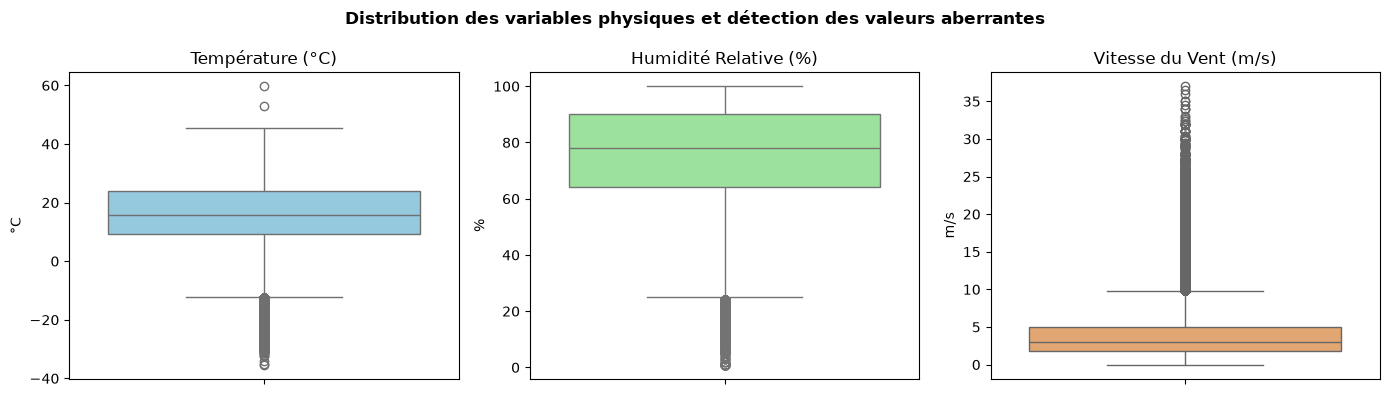

In [44]:
# Préparer les données de température en Celsius pour l'affichage
df_meteo['t_celsius'] = df_meteo['t'] - 273.15

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Température (°C)
sns.boxplot(y=df_meteo['t_celsius'], ax=axes[0], color='skyblue')
axes[0].set_title('Température (°C)')
axes[0].set_ylabel('°C')

# 2. Humidité (%)
sns.boxplot(y=df_meteo['u'], ax=axes[1], color='lightgreen')
axes[1].set_title('Humidité Relative (%)')
axes[1].set_ylabel('%')

# 3. Vitesse du Vent (m/s)
sns.boxplot(y=df_meteo['ff'], ax=axes[2], color='sandybrown')
axes[2].set_title('Vitesse du Vent (m/s)')
axes[2].set_ylabel('m/s')

plt.suptitle('Distribution des variables physiques et détection des valeurs aberrantes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [45]:
#Conversion de validity_time en type Datetime
df_meteo['validity_time'] = pd.to_datetime(df_meteo['validity_time'], utc=True)

In [46]:
#Extraction facile des variables temporelles utiles pour l'épidémiologie
df_meteo['annee'] = df_meteo['validity_time'].dt.year
df_meteo['mois'] = df_meteo['validity_time'].dt.month
df_meteo['jour'] = df_meteo['validity_time'].dt.day
df_meteo['heure'] = df_meteo['validity_time'].dt.hour
df_meteo['jour_semaine'] = df_meteo['validity_time'].dt.day_name() # Lundi, Mardi...
df_meteo['date_jour'] = df_meteo['validity_time'].dt.date         # AAAA-MM-JJ (pour jointure santé)

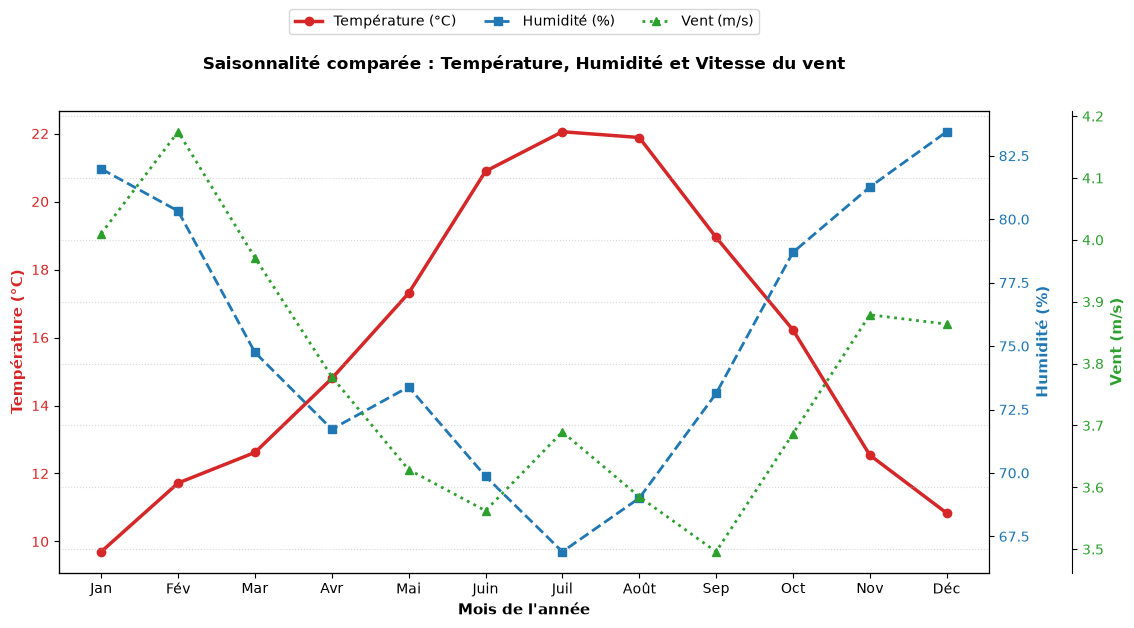

In [ ]:
# moyenne mensuelle des variables d'intérêt pour la saisonnalité
df_saison = df_meteo.groupby('mois')[['t_celsius', 'u', 'ff']].mean().reset_index()

#Création de la figure à 3 axes Y
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axe 1 : Température (°C)
color1 = 'tab:red'
ax1.set_xlabel('Mois de l\'année', fontsize=11, fontweight='bold')
ax1.set_ylabel('Température (°C)', color=color1, fontsize=11, fontweight='bold')
line1 = ax1.plot(df_saison['mois'], df_saison['t_celsius'], color=color1, marker='o', linewidth=2.5, label='Température (°C)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc'])

# Axe 2 : Humidité (%)
ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Humidité (%)', color=color2, fontsize=11, fontweight='bold')
line2 = ax2.plot(df_saison['mois'], df_saison['u'], color=color2, marker='s', linestyle='--', linewidth=2, label='Humidité (%)')
ax2.tick_params(axis='y', labelcolor=color2)

# Axe 3 : Vitesse du Vent (m/s)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60)) # Décaler le 3ème axe vers la droite
color3 = 'tab:green'
ax3.set_ylabel('Vent (m/s)', color=color3, fontsize=11, fontweight='bold')
line3 = ax3.plot(df_saison['mois'], df_saison['ff'], color=color3, marker='^', linestyle=':', linewidth=2, label='Vent (m/s)')
ax3.tick_params(axis='y', labelcolor=color3)

# Légende combinée
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=True)

plt.title("Saisonnalité comparée : Température, Humidité et Vitesse du vent", fontsize=12, fontweight='bold', pad=30)
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()

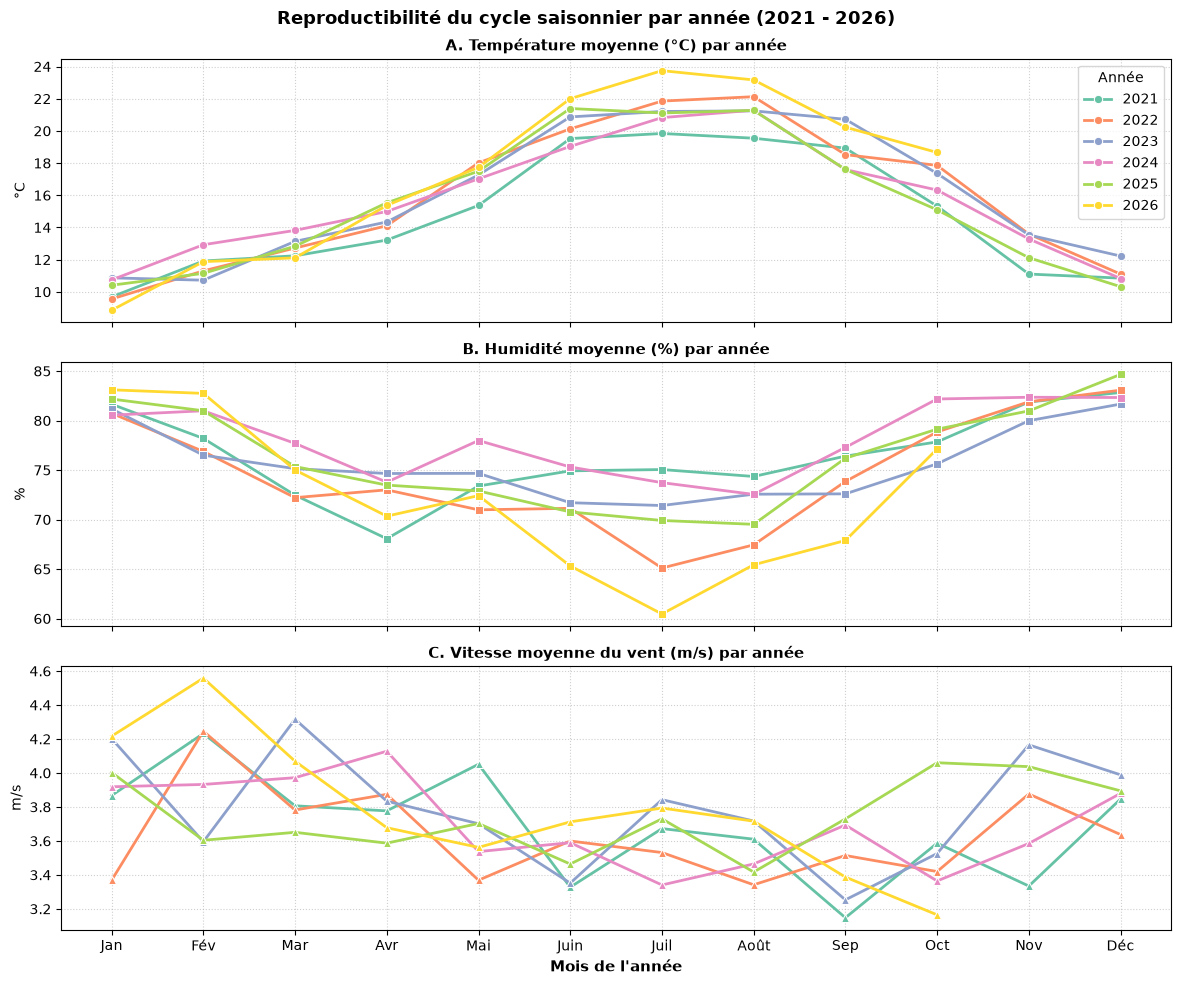

In [49]:

# Calcul des moyennes mensuelles par année
if 't_celsius' not in df_meteo.columns:
    df_meteo['t_celsius'] = df_meteo['t'] - 273.15

df_annee_mois = df_meteo.groupby(['annee', 'mois'])[['t_celsius', 'u', 'ff']].mean().reset_index()

#Création de la figure à 3 sous-graphiques
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
annees = sorted(df_annee_mois['annee'].unique())
palette = sns.color_palette("Set2", len(annees))

# Graphique A : Température
sns.lineplot(data=df_annee_mois, x='mois', y='t_celsius', hue='annee', palette=palette, marker='o', linewidth=2, ax=axes[0])
axes[0].set_title('A. Température moyenne (°C) par année', fontsize=11, fontweight='bold')
axes[0].set_ylabel('°C')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(title='Année', loc='upper right')

# Graphique B : Humidité
sns.lineplot(data=df_annee_mois, x='mois', y='u', hue='annee', palette=palette, marker='s', linewidth=2, ax=axes[1], legend=False)
axes[1].set_title('B. Humidité moyenne (%) par année', fontsize=11, fontweight='bold')
axes[1].set_ylabel('%')
axes[1].grid(True, linestyle=':', alpha=0.6)

# Graphique C : Vitesse du vent
sns.lineplot(data=df_annee_mois, x='mois', y='ff', hue='annee', palette=palette, marker='^', linewidth=2, ax=axes[2], legend=False)
axes[2].set_title('C. Vitesse moyenne du vent (m/s) par année', fontsize=11, fontweight='bold')
axes[2].set_ylabel('m/s')
axes[2].set_xlabel('Mois de l\'année', fontsize=11, fontweight='bold')
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc'])
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Reproductibilité du cycle saisonnier par année (2021 - 2026)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()